# Machine Learning for Thermal Engineers
## Lesson 7: Feature Scaling and Normalization

Author: Srikantan Natarajan

# 1. Problem Motivation

Machine learning models are sensitive to the scale of input features.

For example, in an HVAC dataset:

- Solar load may be on the order of hundreds
- Humidity may be on the order of tens
- Temperature error may be on the order of single digits

If these variables are used directly, their coefficients can become difficult to compare.

This becomes especially important when using:

- Ridge regression
- Lasso regression
- Neural networks

Feature scaling helps place variables on a comparable numerical basis.

# 2. Mathematical Intuition

A common scaling method is **standardization**:

$$
x' = \frac{x - \mu}{\sigma}
$$

Where:

- $x$ = original feature
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature
- $x'$ = standardized feature

After standardization:

- the feature mean becomes approximately 0
- the feature standard deviation becomes approximately 1

This allows machine learning models to treat different variables more fairly.

# 3. Engineering Analogy

Scaling is similar to converting engineering quantities to a common normalized basis before comparing them.

For example, if one variable is measured in:

- hundreds of W/m²
- tens of percent
- single-digit temperature differences

then comparing raw coefficients directly can be misleading.

Feature scaling does not change the underlying physics.

It simply puts variables on a comparable numerical scale so that the model can learn more fairly and coefficient interpretation becomes clearer.

# 4. Create a Synthetic HVAC Dataset

We generate a synthetic HVAC-style dataset using:

- Ambient temperature
- Solar load
- Humidity
- Cabin temperature
- Set temperature

We then create two derived features:

- TempError
- CoolingIndex

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [2]:
n_samples = 200

ambient_temp = np.random.uniform(25, 45, n_samples)
solar_load = np.random.uniform(200, 1000, n_samples)
humidity = np.random.uniform(30, 80, n_samples)
cabin_temp = np.random.uniform(22, 45, n_samples)
set_temp = np.random.uniform(18, 24, n_samples)

noise = np.random.normal(0, 0.25, n_samples)

compressor_power = (
    0.05 * ambient_temp
    + 0.0015 * solar_load
    + 0.015 * humidity
    + 0.12 * cabin_temp
    - 0.10 * set_temp
    + noise
)

In [3]:
df = pd.DataFrame({
    "AmbientTemp": ambient_temp,
    "SolarLoad": solar_load,
    "Humidity": humidity,
    "CabinTemp": cabin_temp,
    "SetTemp": set_temp,
    "CompressorPower": compressor_power
})

df["TempError"] = df["CabinTemp"] - df["SetTemp"]
df["CoolingIndex"] = df["TempError"] * (df["SolarLoad"] / 1000)

df.head()

,AmbientTemp,SolarLoad,Humidity,CabinTemp,SetTemp,CompressorPower,TempError,CoolingIndex
0,32.490802,713.625317,35.156193,25.885506,22.243432,4.148664,3.642075,2.599077
1,44.014286,267.311972,75.127645,28.407578,18.915234,4.912147,9.492344,2.537417
2,39.639879,329.302971,55.262619,26.071241,21.457730,4.382713,4.613511,1.519243
3,36.973170,918.843351,71.322873,24.040158,21.640290,5.170203,2.399868,2.205103
4,28.120373,685.143248,46.002480,24.774625,20.544784,4.182195,4.229841,2.898047


# 5. Prepare the Feature Matrix

We use the following features:

- AmbientTemp
- SolarLoad
- Humidity
- TempError
- CoolingIndex

The target variable is compressor power.

In [4]:
features = ["AmbientTemp", "SolarLoad", "Humidity", "TempError", "CoolingIndex"]

X = df[features]
y = df["CompressorPower"]

# 6. Ridge Regression Without Scaling

We first train a Ridge regression model using the raw, unscaled features.

This will help us see how coefficient magnitudes can be misleading when variables have different scales.

In [5]:
ridge_no_scaling = Ridge(alpha=1.0)
ridge_no_scaling.fit(X, y)

coef_no_scaling = pd.DataFrame({
    "Feature": features,
    "Coefficient": ridge_no_scaling.coef_
})

coef_no_scaling

,Feature,Coefficient
0,AmbientTemp,0.043857
1,SolarLoad,0.001734
2,Humidity,0.016901
3,TempError,0.126733
4,CoolingIndex,-0.015083


# 7. Ridge Regression With Scaling

Now we standardize the features and train Ridge regression again.

This gives all variables a comparable scale and makes coefficient interpretation more meaningful.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge_scaled = Ridge(alpha=1.0)
ridge_scaled.fit(X_scaled, y)

coef_scaled = pd.DataFrame({
    "Feature": features,
    "Coefficient": ridge_scaled.coef_
})

coef_scaled

,Feature,Coefficient
0,AmbientTemp,0.255253
1,SolarLoad,0.374204
2,Humidity,0.256895
3,TempError,0.786186
4,CoolingIndex,-0.028068


# 8. Compare Coefficients

The following plot compares Ridge coefficients with and without scaling.

This illustrates how raw coefficient magnitudes can be misleading when features have very different numerical ranges.

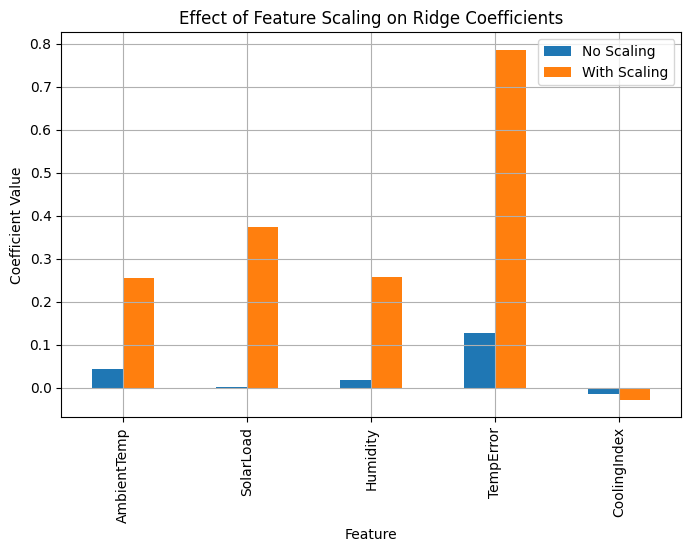

In [7]:
coef_compare = pd.DataFrame({
    "Feature": features,
    "No Scaling": ridge_no_scaling.coef_,
    "With Scaling": ridge_scaled.coef_
})

coef_compare.set_index("Feature").plot(kind="bar", figsize=(8, 5))
plt.title("Effect of Feature Scaling on Ridge Coefficients")
plt.ylabel("Coefficient Value")
plt.grid(True)
plt.show()

# 9. Visualization and Interpretation

Without scaling:

- features with large numerical magnitudes tend to receive small coefficients
- features with smaller numerical magnitudes may receive larger coefficients

This does **not** necessarily mean one feature is more physically important than another.

With scaling:

- coefficients become more directly comparable
- regularization behaves more fairly
- feature influence is easier to interpret

# 10. Key Takeaways

- Feature scaling is essential when variables have very different magnitudes
- Scaling is especially important for Ridge, Lasso, and neural networks
- Raw coefficient values can be misleading without scaling
- Standardization helps the model treat all features more fairly
- Scaling improves both numerical stability and interpretability

# 11. Try It Yourself

Try the following experiments:

1. Add `CabinTemp` and `SetTemp` separately and compare the coefficients
2. Replace Ridge with Lasso and observe how scaling affects feature elimination
3. Modify the synthetic compressor power equation to make `CoolingIndex` more dominant
4. Add a new engineered feature related to thermal soak or solar amplification

In [8]:
scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Means after scaling:")
print(scaled_df.mean().round(4))

print("\nStandard deviations after scaling:")
print(scaled_df.std().round(4))

Means after scaling:
AmbientTemp     0.0
SolarLoad       0.0
Humidity       -0.0
TempError       0.0
CoolingIndex   -0.0
dtype: float64

Standard deviations after scaling:
AmbientTemp     1.0025
SolarLoad       1.0025
Humidity        1.0025
TempError       1.0025
CoolingIndex    1.0025
dtype: float64
